In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
data_dir = '/content/drive/MyDrive/AI_model/src/processed_data'

X_train = joblib.load(
    f'{data_dir}/X_train.pkl'
)

X_val = joblib.load(
    f'{data_dir}/X_val.pkl'
)

y_train = joblib.load(
    f'{data_dir}/y_train.pkl'
)

y_val = joblib.load(
    f'{data_dir}/y_val.pkl'
)

In [ ]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (1600, 20)
X_val: (400, 20)
y_train: (1600,)
y_val: (400,)


In [ ]:
model_dir = '/content/drive/MyDrive/AI_model/model'

In [ ]:
models = {
    'Logistic Regression': joblib.load(
        f'{model_dir}/logistic_regression.pkl'
    ),
    'KNN': joblib.load(
        f'{model_dir}/knn.pkl'
    ),
    'SVM': joblib.load(
        f'{model_dir}/svm.pkl'
    ),
    'Naive Bayes': joblib.load(
        f'{model_dir}/naive_bayes.pkl'
    )
}

In [ ]:
results = []

predictions = {}

for name, model in models.items():

    y_pred = model.predict(X_val)

    predictions[name] = y_pred

    accuracy = accuracy_score(
        y_val,
        y_pred
    )

    precision = precision_score(
        y_val,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_val,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_val,
        y_pred,
        average='weighted'
    )

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1
    })

In [ ]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='F1-score',
    ascending=False
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.9750,0.975946,0.9750,0.975020
2,SVM,0.8925,0.895561,0.8925,0.893296
3,Naive Bayes,0.7975,0.806132,0.7975,0.799422
1,KNN,0.5300,0.569762,0.5300,0.540707


In [ ]:
results_df.to_csv(
    f'{data_dir}/evaluation_results.csv',
    index=False
)

In [ ]:
eval_dir = '/content/drive/MyDrive/AI_model/figure/evaluation'

os.makedirs(
    eval_dir,
    exist_ok=True
)

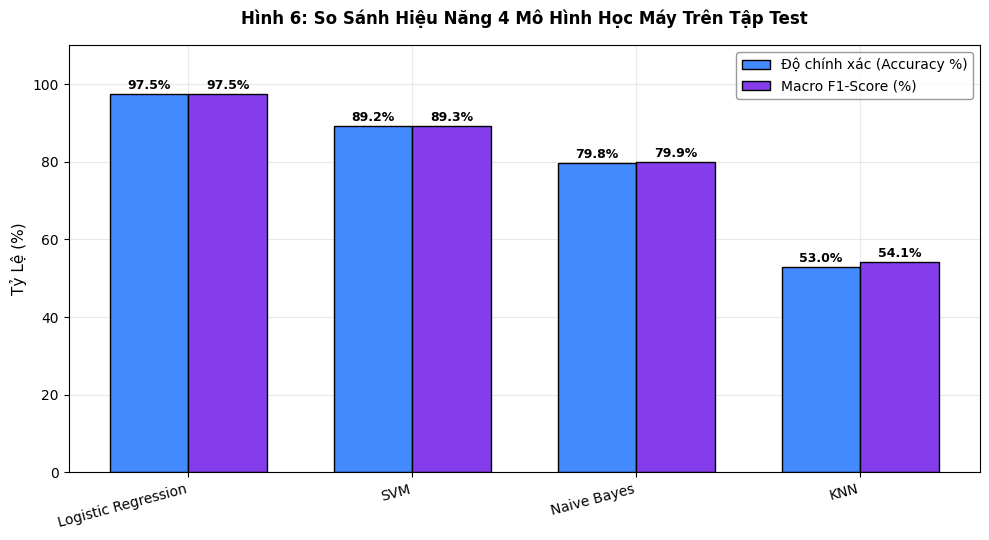

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Tạo kích thước hình vẽ
plt.figure(figsize=(10, 5.5))

x = np.arange(len(results_df))
width = 0.35  # Độ rộng của mỗi cột

# Chuyển đổi điểm số sang dạng phần trăm (%)
acc_pct = results_df['Accuracy'] * 100
f1_pct = results_df['F1-score'] * 100

# Vẽ 2 cột tương ứng với Accuracy và F1-Score
bars1 = plt.bar(
    x - width/2,
    acc_pct,
    width,
    label='Độ chính xác (Accuracy %)',
    color='#438afe',
    edgecolor='black'
)
bars2 = plt.bar(
    x + width/2,
    f1_pct,
    width,
    label='Macro F1-Score (%)',
    color='#853deb',
    edgecolor='black'
)

# Hiển thị số phần trăm (%) trên đầu mỗi cột
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}%',
             ha='center', va='bottom', fontsize=9, fontweight='bold')

# Thiết lập tiêu đề, nhãn và khoảng giá trị trục Y
plt.title('Hình 6: So Sánh Hiệu Năng 4 Mô Hình Học Máy Trên Tập Test', fontsize=12, fontweight='bold', pad=15)
plt.ylabel('Tỷ Lệ (%)', fontsize=11)
plt.xticks(x, results_df['Model'], rotation=15, ha='right', fontsize=10)
plt.ylim(0, 110)

# Bật lưới xám nhạt phía sau cột
plt.grid(True, linestyle='-', alpha=0.5, color='#d3d3d3')
plt.gca().set_axisbelow(True)

# Hiển thị chú thích
plt.legend(frameon=True, edgecolor='#808080')
plt.tight_layout()

# Lưu biểu đồ vào Drive
plt.savefig(
    f'{eval_dir}/model_comparison_4_models.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

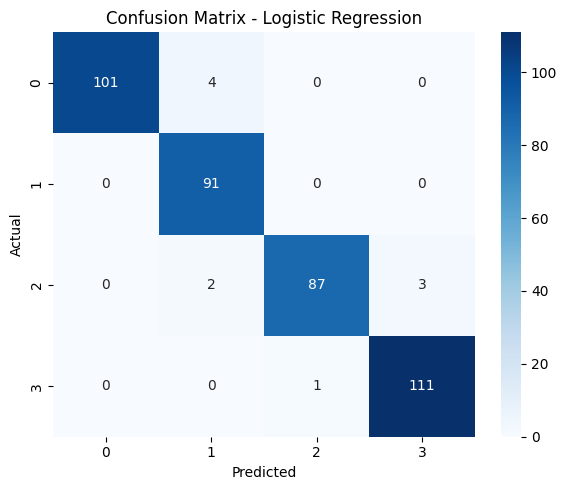

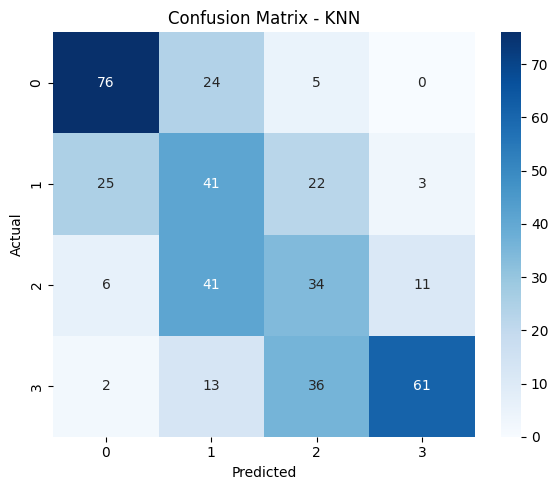

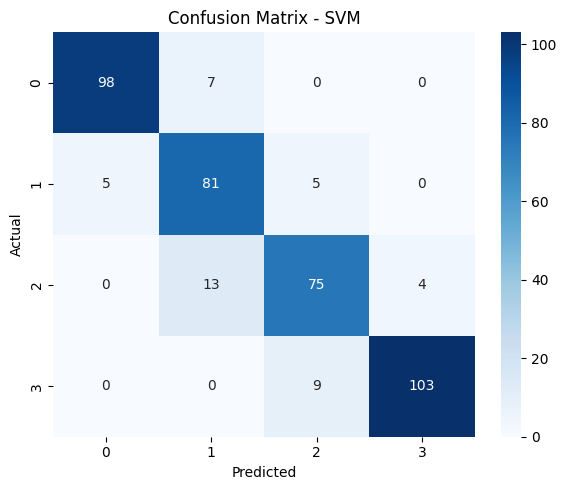

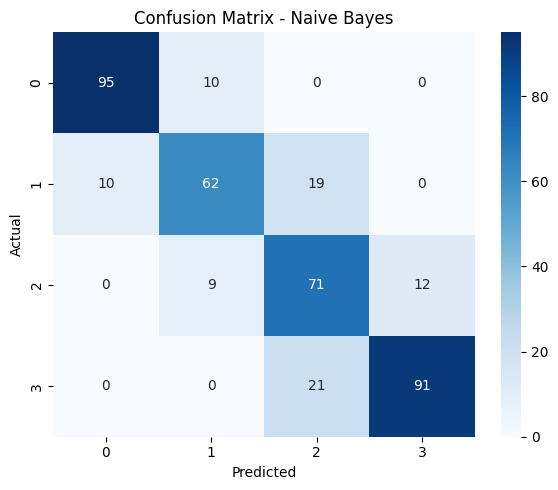

In [ ]:
for name, y_pred in predictions.items():

    cm = confusion_matrix(
        y_val,
        y_pred
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[0, 1, 2, 3],
        yticklabels=[0, 1, 2, 3]
    )

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.title(
        f'Confusion Matrix - {name}'
    )

    plt.tight_layout()

    filename = (
        name.lower()
        .replace(' ', '_')
        + '_confusion_matrix.png'
    )

    plt.savefig(
        f'{eval_dir}/{filename}',
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    plt.close()

In [ ]:
for name, y_pred in predictions.items():

    print('=' * 70)
    print(name)
    print('=' * 70)

    print(
        classification_report(
            y_val,
            y_pred,
            target_names=[
                'Price 0',
                'Price 1',
                'Price 2',
                'Price 3'
            ]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

     Price 0       1.00      0.96      0.98       105
     Price 1       0.94      1.00      0.97        91
     Price 2       0.99      0.95      0.97        92
     Price 3       0.97      0.99      0.98       112

    accuracy                           0.97       400
   macro avg       0.98      0.97      0.97       400
weighted avg       0.98      0.97      0.98       400

KNN
              precision    recall  f1-score   support

     Price 0       0.70      0.72      0.71       105
     Price 1       0.34      0.45      0.39        91
     Price 2       0.35      0.37      0.36        92
     Price 3       0.81      0.54      0.65       112

    accuracy                           0.53       400
   macro avg       0.55      0.52      0.53       400
weighted avg       0.57      0.53      0.54       400

SVM
              precision    recall  f1-score   support

     Price 0       0.95      0.93      0.94    

In [ ]:
best_score = results_df.iloc[0]['F1-score']

print(
    f"F1-score: {best_score:.4f}"
)

F1-score: 0.9750
